# Wakefield and impedance (ABCI)

The wakefield solver runs the bunch through the cavity and reports the wake potentials and the beam-coupling impedance. cavsim2d drives the **ABCI** time-domain solver behind a backend-agnostic interface (`cav.wakefield`). ABCI needs beam pipes at both ends, so the cavity is built with `beampipe='both'`.

> This example needs the bundled `ABCI.exe` (Windows, or `wine` elsewhere) — see the installation page.

See the [wakefield guide](../../wakefield).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. The cavity

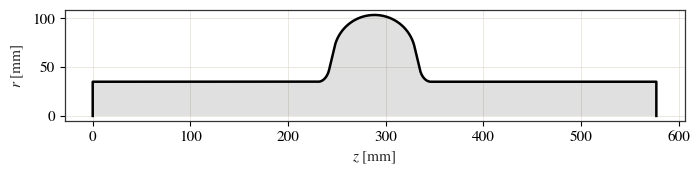

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]
cav = EllipticalCavity(1, midcell, midcell, midcell, beampipe='both', name='wake')
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'wake'))

cav.plot('geometry')

## 2. Run the wakefield solve

`MROT=2` computes both the longitudinal and transverse polarisations; `wakelength` is the length of wake to compute [m] and `bunch_length` the rms bunch length [mm].

In [3]:
cav.wakefield.run({'MROT': 2, 'wakelength': 20, 'bunch_length': 25})
cav.wakefield.qois

{'|k_loss| [V/pC]': 0.1803,
 'k_FM [V/pC]': 0.14338,
 'k_loss_HOM [V/pC]': 0.03691999999999998,
 '|k_kick| [V/pC/m]': 5.774}

## 3. Impedance spectra

The longitudinal impedance $|Z_\parallel|$ vs frequency (its peaks are the cavity's higher-order modes):

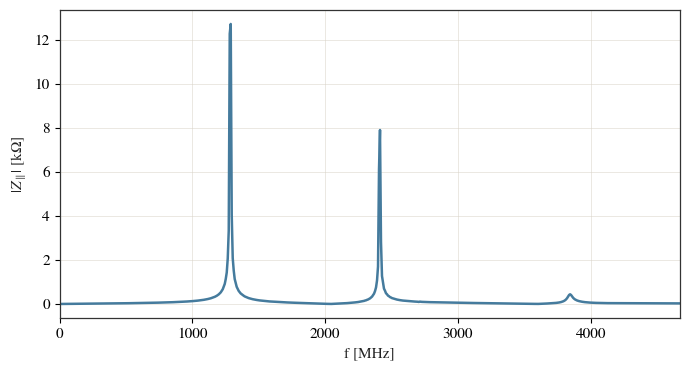

<Axes: xlabel='f [MHz]', ylabel='$|Z_\\parallel|$ [k$\\Omega$]'>

In [4]:
cav.wakefield.plot_impedance('longitudinal')

The transverse (dipole) impedance $|Z_\perp|$:

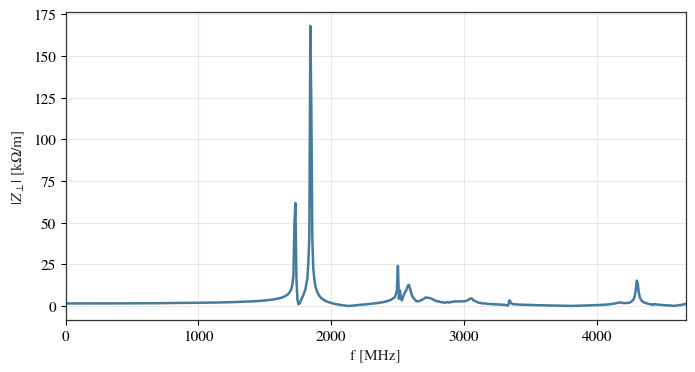

<Axes: xlabel='f [MHz]', ylabel='$|Z_\\perp|$ [k$\\Omega$/m]'>

In [5]:
cav.wakefield.plot_impedance('transverse')

## 4. Wake potential and loss factor

The longitudinal wake potential behind the bunch head:

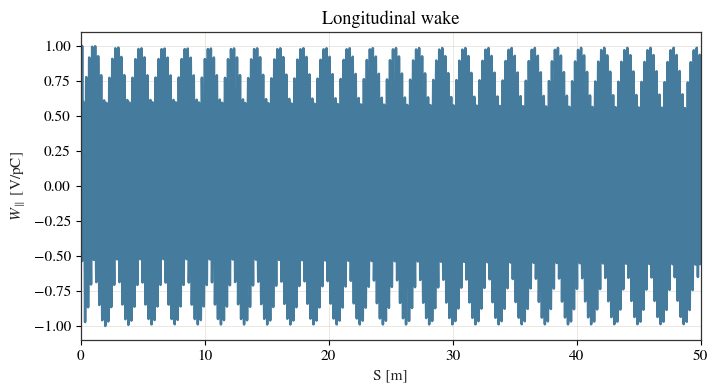

<Axes: title={'center': 'Longitudinal wake'}, xlabel='S [m]', ylabel='$W_\\parallel$ [V/pC]'>

In [6]:
cav.wakefield.plot_wake('longitudinal')

The cumulative loss-factor spectrum $k_\mathrm{loss}(F)$:

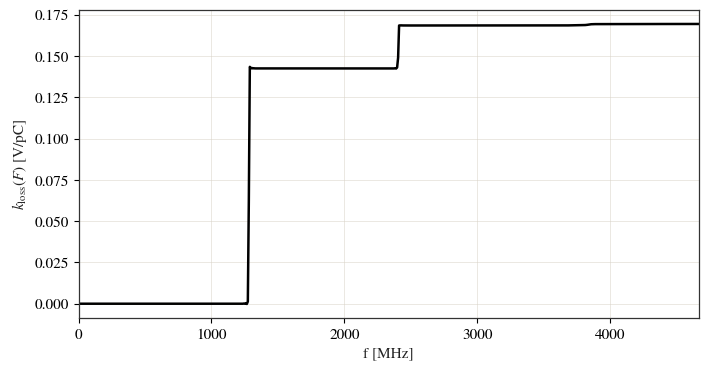

<Axes: xlabel='f [MHz]', ylabel='$k_{\\mathrm{loss}}(F)$ [V/pC]'>

In [7]:
cav.wakefield.plot_k_loss()

## Compare with the eigenmode reconstruction

The eigenmode solver reconstructs the same impedance from its modes — `cav.eigenmode.plot_impedance()` — on the same axes as `cav.wakefield.plot_impedance()` (both default to kOhm) they can be overlaid; see the [eigenmode example](../eigenmode/elliptical_tesla.ipynb).